<a href="https://colab.research.google.com/github/Luiz-castilho/CalculoNumerico/blob/main/atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


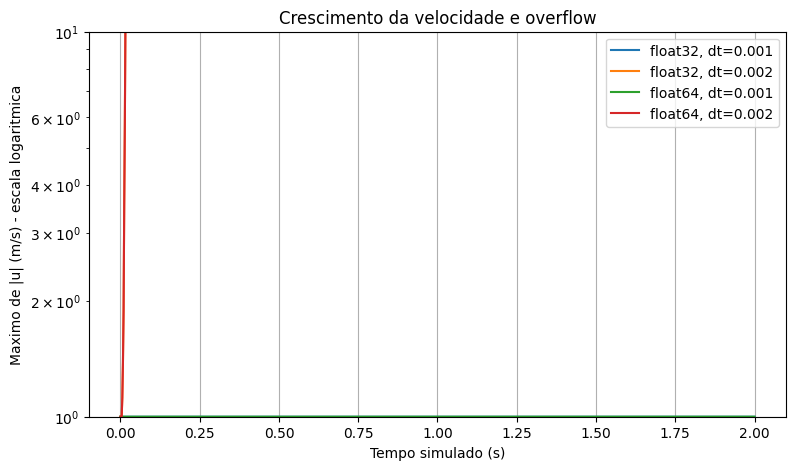

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

Caso A é estavel, já que r < 1/2, e o caso B é instavel (r > 1/2)

3

Isso ocorre pois o método de diferenças finitas apresenta certas limitações, quando tempo total é superior ao limite a função saí de controle indo para valores incoerentes com o cenário real, justamente por isso que se atentar ao valor limitante da função definida por (dy_**2)/(2*1e-4)

In [28]:
#Simulação
import pandas as pd

tab_part2 = []
for nome, resultado in resultados.items():

    tipo_nome = "float32" if "float32" in nome else "float64"
    dt_val = nome.split("dt=")[-1].strip()
    fal = resultado["falha"]
    ocorreu_overflow = "Sim" if fal is not None else "Não"
    passo_falha = fal if fal is not None else " -- "

    tab_part2.append({
        "Tipo Numérico": tipo_nome,
        "Passo de Tempo (dt)": dt_val,
        "Valor de r": resultado["r"],
        "Ocorreu Overflow?": ocorreu_overflow,
        "Iteração/Passo da Falha": passo_falha
    })
df_tab_part2 = pd.DataFrame(tab_part2)
display(df_tab_part2)


,Tipo Numérico,Passo de Tempo (dt),Valor de r,Ocorreu Overflow?,Iteração/Passo da Falha
0,float32,0.001,0.4,Não,--
1,float32,0.002,0.8,Sim,121
2,float64,0.001,0.4,Não,--
3,float64,0.002,0.8,Sim,917


4

Para ambos os casos o instabilidade/estabilidade não dependeu do númeor de interações, o que muda é velocidade em que o limite desses tipos são atingidos, sendo 121 para o float32 e 917 para o float64 no caso B

5

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply
dt=0.002, float32: falha no passo 38, t=0.0760 s - overflow encountered in multiply
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
dt=0.002, float64: falha no passo 291, t=0.5820 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


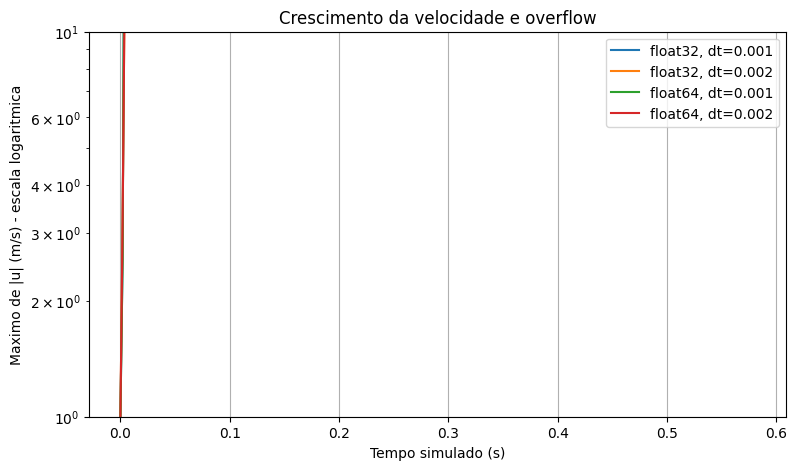

In [13]:

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados2 = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados2[nome] = simular(dt, tipo, pontos=41)

plt.figure(figsize=(9, 5))

for nome, resultado2 in resultados2.items():
    plt.semilogy(
        resultado2["tempos"],
        resultado2["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
dy_ = 0.01/40
limite_ = (dy_**2)/(2*1e-4)
print(dy_)
print(limite_)

0.00025
0.00031249999999999995


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply
dt=0.002, float32: falha no passo 38, t=0.0760 s - overflow encountered in multiply
dt=0.001, float64: 300 passos sem overflow.
dt=0.002, float64: falha no passo 291, t=0.5820 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


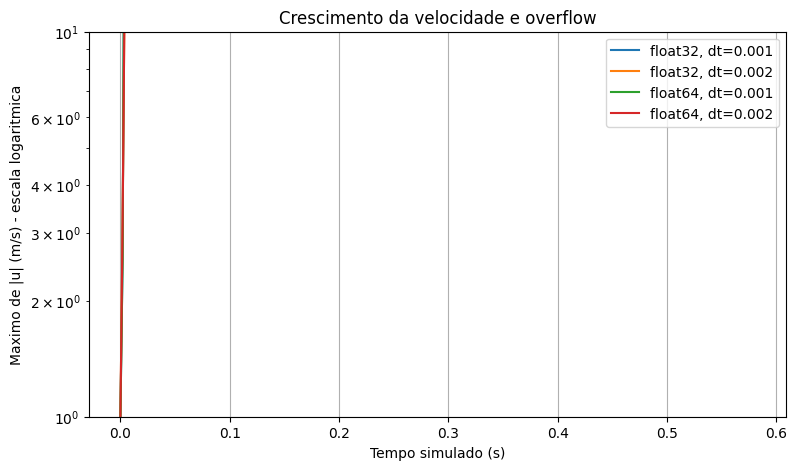

In [18]:

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados3 = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados3[nome] = simular(dt, tipo, passos=300, pontos=41 )

plt.figure(figsize=(9, 5))

for nome, resultado3 in resultados2.items():
    plt.semilogy(
        resultado3["tempos"],
        resultado3["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

6

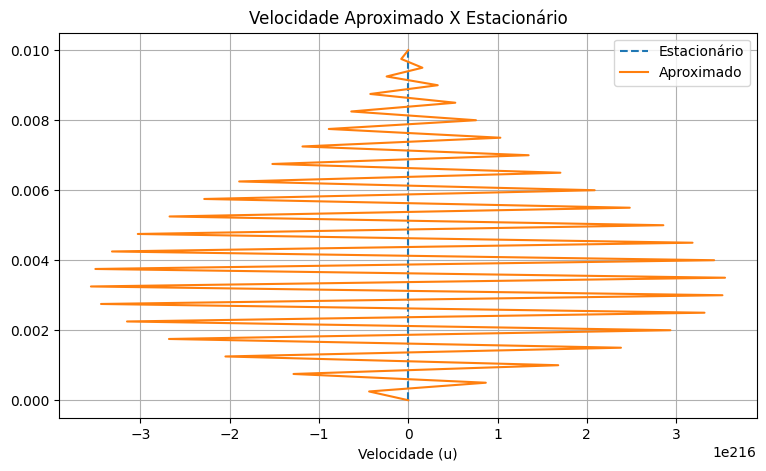

Diferença máxima: 3.553109e+216


In [25]:

# passos= 300,
res_est = resultados3['float64, dt=0.001']
y = res_est['y']
H = 0.01
U = 1.0

u_sim = res_est['u']



uest_teorico = U * (1 - y / H)


plt.figure(figsize=(9, 5))
plt.plot(uest_teorico, y, label='Estacionário', linestyle='--')
plt.plot(u_sim, y, label='Aproximado')

plt.xlabel('Velocidade (u)')

plt.title('Velocidade Aproximado X Estacionário')
plt.grid(True)
plt.legend()
plt.show()

max_dif = np.max(np.abs(u_sim - uest_teorico))

print(f"Diferença máxima: {max_dif:.6e}")

Dado o comportamento do grafico do valor simulado o tempo não foi suficiente, basta ver as oscilações e o valor máximo do erro que é de ordem 10^216, devido a instabilidade da simulação não permitiu que ela atingisse um valor proximo da estacionária, sendo assim o efeito do transiente concluído ou não demonstra-se irrelevante.

7

Conclusão: O refinamento da malha e o passo estão diretamente ligados, ja que quanto maior o refinamento menor será o passo necessário, já em relação a r esse efeito é oposto, sendo assim são grandezas relacionadas. O overflow vai não vai alterar a instabilidade, mas prolonga a quantidade de passos até o valor passe do limite. Na simulação o que corrigiu do t = 0,001 foi escolher um passo menor do que tempo maximo, regido pela função (dy_**2)/(2*1e-4) reforçando como essas grandezas estão ligadas.